### Pseudo-OHLC Data Generation

We can generate synthetic OHLC chart and use this fake chart to train our model

### Here a real chart of BTCUSDT at random hour

In [21]:
import pandas as pd
from dataWorker import *


start,end,duration,df = getRandomIntervalData('BTCUSDT', 120, normalize=True)

df.to_parquet(f"data/real/btcusdt_{duration}_{start}_{end}.parquet", index=False)

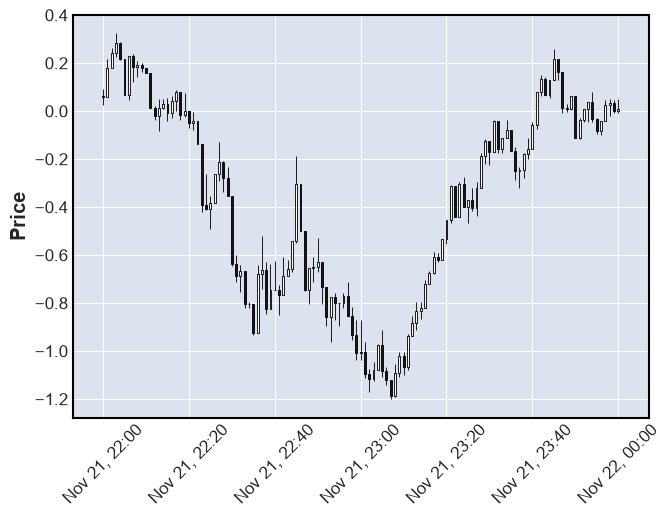

In [22]:
import mplfinance as mpf

#index
df = df.set_index("timestamp")
# plotting
mpf.plot(df, type='candle')


### Here we generate synthetic chart

Using _**Gaussian Distribution**_ for candle body generation and _**Student's t-distribution**_ for wick is best way to generate synthetic chart

In [26]:
import random
import numpy as np

def distribution(sigma=0.2, mode="gauss", df=3, high=None):
    
    
    
    if mode == "uniform":
        x = random.uniform(-sigma, sigma)
    elif mode == "gauss":
        x = random.gauss(0, sigma)
    elif mode == "student_t":
        x = np.random.standard_t(df) * sigma
        
    if high is not None:
        x = max(min(x, high), -high)
    return x

In [41]:
import pandas as pd
import random

seed = random.randint(1, 2**20)
# for teting
#seed = 751045
random.seed(seed)
np.random.seed(seed)

minutes = 60*24
body_sigma = 0.046
wick_sigma = 0.02
body_df = 4
wick_df = 23

data = [0]*minutes
base_price = 0

for i in range(minutes):
    timestamp = (1784206800 + 60*i)*1000
    if i==0: 
        price_o = base_price
    else:
        price_o = data[i-1][4]
        
    price_c = price_o + distribution(sigma=body_sigma, mode="gauss", df=body_df)
    price_h = max(price_o, price_c) + abs(distribution(sigma=wick_sigma, mode="student_t", df=wick_df))
    price_l = min(price_o, price_c) - abs(distribution(sigma=wick_sigma, mode="student_t", df=wick_df))
        
        
    #              0         1        2        3        4     5  6
    data[i] = [timestamp, price_o, price_h, price_l, price_c, 1, 1]

columns = ["timestamp", "open", "high", "low", "close", "volume", "quote_volume"]
df = pd.DataFrame(data, columns=columns)


df.to_parquet(f"data/synthetic/train/mins_{minutes}_seed{seed}_bodysigma{str(body_sigma).replace('.','')}_wickdf{wick_df}.parquet", index=False)

Seed: 525284


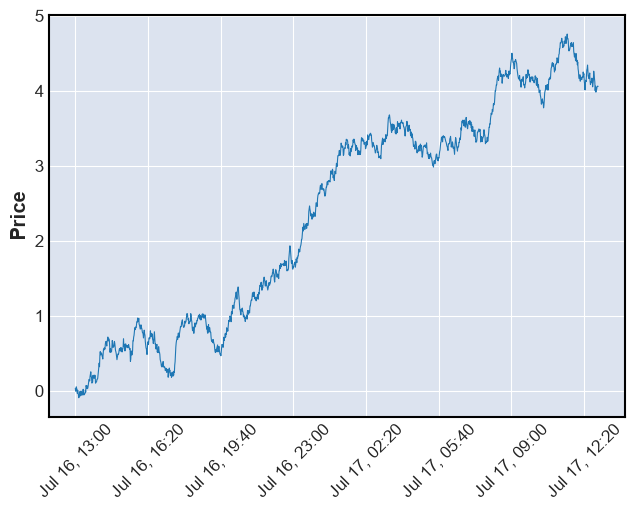

In [42]:
import mplfinance as mpf

df["timestamp"] = pd.to_datetime(df["timestamp"].astype("int64"), unit="ms")
#index
df = df.set_index("timestamp")
# plotting
print(f"Seed: {seed}")
mpf.plot(df, type='line')